In [ ]:
import os
import copy
import json
import time
from pathlib import Path
import yaml
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sys
sys.path.append("../src")

from Data.prepare_data import create_sliding_windows, train_split
from Data.preprocessing import normalize_tp



from Dataset_Utils import station_dictionary, grafo_distancias, tensor_data, reset_weights

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

RUN_MODE = "quick"  # quick or full
if RUN_MODE == "full":
    start_date = "2014-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2020-01-01"
    end_date = "2025-12-31"

#train_period = 30
#hidden_dim = 64
#lr = 1e-3
#weight_decay = 5e-4
criterion_km = 115
batch_size = 16
num_workers = 0  # Windows-safe default

#out_root = Path(r"C:\Climate Change Project\Simulations\MULTIVAR_modelsv1\BENCHMARK_BATCHED")
#out_root.mkdir(parents=True, exist_ok=True)
#run_dir = out_root / f"run_{int(time.time())}"
#run_dir.mkdir(parents=True, exist_ok=True)
#print("run_dir:", run_dir)



ImportError: cannot import name 'normalize_tp' from 'Data.preprocessing' (c:\Local Reposity\LSTM-GNN\Notebooks\../src\Data\preprocessing.py)

In [4]:
def assert_finite(name, tensor):
    if not torch.isfinite(tensor).all():
        nan_count = torch.isnan(tensor).sum().item()
        inf_count = torch.isinf(tensor).sum().item()
        raise RuntimeError(f"{name} has non-finite values (nan={nan_count}, inf={inf_count})")


def safe_r2(y_true, y_pred, eps=1e-8):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1.0 - (ss_res / (ss_tot + eps))


def safe_mape(y_true, y_pred, eps=1e-3):
    return (torch.abs(y_pred - y_true) / (torch.abs(y_true) + eps)).mean() * 100.0


def save_error_plots(path, train_mse, val_mse, train_mae, val_mae, train_r2, val_r2):
    metrics = [
        ("mse", train_mse, val_mse, "MSE"),
        ("mae", train_mae, val_mae, "MAE"),
        ("r2", train_r2, val_r2, "R2"),
    ]

    for metric_name, train_values, val_values, y_label in metrics:
        plt.figure(figsize=(12, 6))
        if len(train_values) > 0:
            plt.plot(train_values, label="train", linewidth=2)
        if len(val_values) > 0:
            plt.plot(val_values, label="val", linewidth=2)

        plt.xlabel("Epoch")
        plt.ylabel(y_label)
        plt.title(f"{y_label} by epoch")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(path, f"{metric_name}_curve.png"), dpi=150)
        plt.close()


def normalize_tp(tp, eps=1e-6):
    tp_log = torch.log1p(tp)
    mean = tp_log.mean()
    std = tp_log.std()
    return (tp_log - mean) / (std + eps), mean, std


def create_sliding_window(X, period):
    T = X.shape[0]
    Xs, ys = [], []
    for t in range(T - period):
        Xs.append(X[t : t + period - 1])
        ys.append(X[t + period - 1, :, 0])
    return torch.stack(Xs), torch.stack(ys)


def adjacency_matrix(N_local, edge_index, edge_weight=None):
    A = torch.eye(N_local, device=edge_index.device)
    if edge_weight is None:
        edge_weight = torch.ones(edge_index.shape[1], device=edge_index.device)
    for i in range(0, len(edge_index[0]), 2):
        u, v = edge_index[0][i], edge_index[0][i + 1]
        A[u, v] = edge_weight[i]
        A[v, u] = edge_weight[i]
    return A


def daily_vertical_velocity(ds, var_name, percentiles=[10]):
    da = ds[var_name]
    daily_mean = da.resample(time="1D").mean()
    daily_min = da.resample(time="1D").min()
    daily_max = da.resample(time="1D").max()
    q = [p / 100 for p in percentiles]
    daily_percentiles = da.resample(time="1D").quantile(q)

    data_vars = {
        f"{var_name}_mean": daily_mean,
        f"{var_name}_min": daily_min,
        f"{var_name}_max": daily_max,
    }
    for i, p in enumerate(percentiles):
        data_vars[f"{var_name}_p{p}"] = daily_percentiles.isel(quantile=i)
    return xr.Dataset(data_vars)


def get_vv(t1, t2, ds, stations):
    N_local = len(stations)
    T = (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1
    X = torch.zeros((T, N_local, 12), dtype=torch.float32)
    da = ds.sel(time=slice(t1, t2))

    for i, station in enumerate(stations.keys()):
        lat, lon = stations[station][0], stations[station][1]
        da_sel = da.sel(latitude=lat, longitude=lon, method="nearest")
        X[:, i, 0:3] = torch.tensor(da_sel.w_mean.values, dtype=torch.float32)
        X[:, i, 3:6] = torch.tensor(da_sel.w_max.values, dtype=torch.float32)
        X[:, i, 6:9] = torch.tensor(da_sel.w_min.values, dtype=torch.float32)
        X[:, i, 9:12] = torch.tensor(da_sel.w_p10.values, dtype=torch.float32)
    return X

def daily_temp_features(ds, day_shift_hours=0):
    # Ajuste de corte diário (se precisar alinhar com o mesmo "dia" da precipitação)
    if day_shift_hours != 0:
        ds = ds.assign_coords(time=ds.time + np.timedelta64(day_shift_hours, "h"))

    # Kelvin -> Celsius (opcional para NN, mas melhor para interpretação física)
    t2m = ds["t2m"] - 273.15
    d2m = ds["d2m"] - 273.15

    out = xr.Dataset({
        "t2m_mean": t2m.resample(time="1D").mean(),
        "t2m_min":  t2m.resample(time="1D").min(),
        "t2m_max":  t2m.resample(time="1D").max(),
        "d2m_mean": d2m.resample(time="1D").mean(),
        "d2m_min":  d2m.resample(time="1D").min(),
        "d2m_max":  d2m.resample(time="1D").max(),
    })
    return out

def get_temp(t1, t2, ds_daily, stations):
    """
    retorna tensor [T, N, 6] com medidas de 
    média de t2m
    max de t2m
    min t2m
    mean d2m
    max d2m
    min d2m
    """
    N = len(stations)
    T = (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1
    X = torch.zeros((T, N, 6), dtype=torch.float32)
    da = ds_daily.sel(time=slice(t1, t2))

    for i, st in enumerate(stations.keys()):
        lat, lon = stations[st][0], stations[st][1]
        s = da.sel(latitude=lat, longitude=lon, method="nearest")
        X[:, i, 0] = torch.tensor(s.t2m_mean.values, dtype=torch.float32)
        X[:, i, 1] = torch.tensor(s.t2m_min.values,  dtype=torch.float32)
        X[:, i, 2] = torch.tensor(s.t2m_max.values,  dtype=torch.float32)
        X[:, i, 3] = torch.tensor(s.d2m_mean.values, dtype=torch.float32)
        X[:, i, 4] = torch.tensor(s.d2m_min.values,  dtype=torch.float32)
        X[:, i, 5] = torch.tensor(s.d2m_max.values,  dtype=torch.float32)
    return X

import re

def create_next_experiment_folder(base_path):
    os.makedirs(base_path, exist_ok=True)
    
    existing = [
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d)) and d.startswith("exp_")
    ]
    
    numbers = []
    for folder in existing:
        match = re.match(r"exp_(\d+)", folder)
        if match:
            numbers.append(int(match.group(1)))
            
    next_number = max(numbers)+1 if numbers else 1
    new_folder_name = f"exp_{next_number:03d}"
    
    full_path = os.path.join(base_path, new_folder_name)
    os.makedirs(full_path)
    
    return full_path


def _infer_coord_name(ds, candidates):
    for c in candidates:
        if c in ds.coords or c in ds.dims:
            return c
    raise ValueError(f"Nenhuma coordenada encontrada entre: {candidates}")

def daily_wind_uv_features(
    ds,
    u_var="u",
    v_var="v",
    levels=(500, 850),
    level_coord=None,
    day_shift_hours=0,
):
    # Descobre nomes de coordenadas automaticamente (ERA5 costuma usar latitude/longitude/level)
    if level_coord is None:
        level_coord = _infer_coord_name(ds, ["level", "pressure_level", "isobaricInhPa"])

    if day_shift_hours != 0:
        ds = ds.assign_coords(time=ds.time + np.timedelta64(day_shift_hours, "h"))

    # Seleciona níveis de pressão desejados
    u = ds[u_var].sel({level_coord: list(levels)})
    v = ds[v_var].sel({level_coord: list(levels)})

    out = xr.Dataset({
        "u_mean": u.resample(time="1D").mean(),
        "u_min":  u.resample(time="1D").min(),
        "u_max":  u.resample(time="1D").max(),
        "v_mean": v.resample(time="1D").mean(),
        "v_min":  v.resample(time="1D").min(),
        "v_max":  v.resample(time="1D").max(),
    })
    return out


def get_wind_uv(t1, t2, ds_daily, stations, levels=(500, 850), level_coord=None):
    """
    Saída: tensor [T, N, 12]
    Ordem dos 12 canais:
      0:2   -> u_mean  (500, 850)
      2:4   -> u_min   (500, 850)
      4:6   -> u_max   (500, 850)
      6:8   -> v_mean  (500, 850)
      8:10  -> v_min   (500, 850)
      10:12 -> v_max   (500, 850)
    """
    if level_coord is None:
        level_coord = _infer_coord_name(ds_daily, ["level", "pressure_level", "isobaricInhPa"])

    lat_name = _infer_coord_name(ds_daily, ["latitude", "lat"])
    lon_name = _infer_coord_name(ds_daily, ["longitude", "lon"])

    N = len(stations)
    T = (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1
    X = torch.zeros((T, N, 12), dtype=torch.float32)

    da = ds_daily.sel(time=slice(t1, t2)).sel({level_coord: list(levels)})

    for i, st in enumerate(stations.keys()):
        lat, lon = stations[st][0], stations[st][1]
        s = da.sel({lat_name: lat, lon_name: lon}, method="nearest")

        X[:, i, 0:2]   = torch.tensor(s.u_mean.values, dtype=torch.float32)
        X[:, i, 2:4]   = torch.tensor(s.u_min.values,  dtype=torch.float32)
        X[:, i, 4:6]   = torch.tensor(s.u_max.values,  dtype=torch.float32)
        X[:, i, 6:8]   = torch.tensor(s.v_mean.values, dtype=torch.float32)
        X[:, i, 8:10]  = torch.tensor(s.v_min.values,  dtype=torch.float32)
        X[:, i, 10:12] = torch.tensor(s.v_max.values,  dtype=torch.float32)

    return X

In [5]:
# Data loading and feature construction

#TENSOR X COM TODAS COVARIAVEIS E DADOS NO FORMATO [T,N,F]
# X[...,0]    : DADOS DE PRECIPITAÇÃO
# X[...,1]    : VARIAVEL PÉRIODICA COM PERIODO 365
# X[...,2:8]  : DADOS DE TEMPERATURA
# X[...,9:15] : DADOS DE VELOCIDADE VERTICAL
# X[...,16,31]: DADOS DE WIND


rea = xr.open_dataset(r"C:\Climate Change Project\Datasets\.nc files\era5_precipitation_80-26.nc")
rea_vv = xr.open_dataset(r"C:\Climate Change Project\Utils\vertical_velocity_data\era5_vv_06-25.nc").sel(time=slice(start_date, None))
rea_temp = xr.open_dataset(r"C:\Climate Change Project\Utils\temperature_data\temp_05-25.nc")
rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc")

catalog_dir = Path(r"C:\Climate Change Project\Datasets\Dados INMET")
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)
N = len(estacoes_RS)

vv_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_dataset = daily_temp_features(rea_temp)
wind_daily = daily_wind_uv_features(rea_wind, u_var='u', v_var='v', levels=(500, 850))
X_wind = get_wind_uv(start_date, end_date, wind_daily, estacoes_RS, levels=(500, 850))


T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1
#X = torch.zeros((T, N, 32), dtype=torch.float32)

X_tp = 1000.0 * torch.tensor(
    tensor_data(pd.to_datetime(start_date), pd.to_datetime(end_date), rea, estacoes_RS),
    dtype=torch.float32, 
).reshape(T, N, 1)


X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_dataset, stations=estacoes_RS)

X_vv = get_vv(start_date, end_date, vv_dataset, estacoes_RS)

X_wind = get_wind_uv(start_date, end_date, wind_daily, estacoes_RS, levels=(500,850))

C:\Users\bruno\AppData\Local\Temp\ipykernel_13236\2647335553.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_tp = 1000.0 * torch.tensor(


In [ ]:
#SEPARAÇÃO EM TRAIN/VALIDATION/TEST
eps = 1e-6


train_period = 30
window       = 15

X = torch.cat([X_tp, X_year, X_temp, X_vv, X_wind], dim=-1)


Xs, ys = create_sliding_window(X, period=train_period)

ys = ys.clamp_min(eps)
Xs[...,0] = Xs[...,0].clamp_min(eps)

num_samples = Xs.shape[0]

n_train = int(0.7 * num_samples)
n_val   = int(0.2 * num_samples)
n_test  = num_samples - n_train - n_val

#separação de train/validation/test data
X_train, y_train = Xs[:n_train], ys[:n_train]
X_val,   y_val   = Xs[n_train:n_train+n_val], ys[n_train:n_train+n_val]
X_test,  y_test  = Xs[n_train+n_val:], ys[n_train+n_val:]


In [452]:
#CRIA A TOPOLOGIA USANDO KNN
from sklearn.neighbors import NearestNeighbors

pos = {}
i=0
coords = np.zeros((N,2))
for name in estacoes_RS.keys():
    pos[i] = float(estacoes_RS[name][1]), float(estacoes_RS[name][0])
    coords[i] = [float(estacoes_RS[name][1]), float(estacoes_RS[name][0])]
    i+=1

k = 5

nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

E_1 = []
E_2 = []
for i in range(N):
    for j in indices[i][1:]:
        E_1.append(i)
        E_2.append(j)
        E_1.append(j)
        E_2.append(i)
edge_index_knn = torch.tensor([E_1,E_2],dtype=torch.int)


"""
graph_data = Data(x=torch.zeros(62), edge_index=edge_index_knn)


G = to_networkx(graph_data, to_undirected=True)

plt.figure(figsize=(30,30))
nx.draw(G,pos,
        with_labels=True,
        node_color='lightblue',
        node_size=700,
        width=3,
        font_weight='bold')



nx.draw_networkx_labels(G,pos,font_color='black')
plt.show()
print("Construido grafo com ",N,"vértices")
"""


'\ngraph_data = Data(x=torch.zeros(62), edge_index=edge_index_knn)\n\n\nG = to_networkx(graph_data, to_undirected=True)\n\nplt.figure(figsize=(30,30))\nnx.draw(G,pos,\n        with_labels=True,\n        node_color=\'lightblue\',\n        node_size=700,\n        width=3,\n        font_weight=\'bold\')\n\n\n\nnx.draw_networkx_labels(G,pos,font_color=\'black\')\nplt.show()\nprint("Construido grafo com ",N,"vértices")\n'

In [ ]:
#NORMALIZA USANDO LOG(1+X) E DEPOIS Z-SCORE

#Normalização pela log(1+x) e depois z-score

var, mean, std = normalize_tp(X_train[...,0])
X_train[...,0] = var
y_train, y_val, y_test = [(torch.log1p(1+y)-mean)/std for y in [y_train, y_val, y_test]]

Xs: (4011, 6, 62, 32) ys: (4011, 62)
train/val/test: 2807 802 402


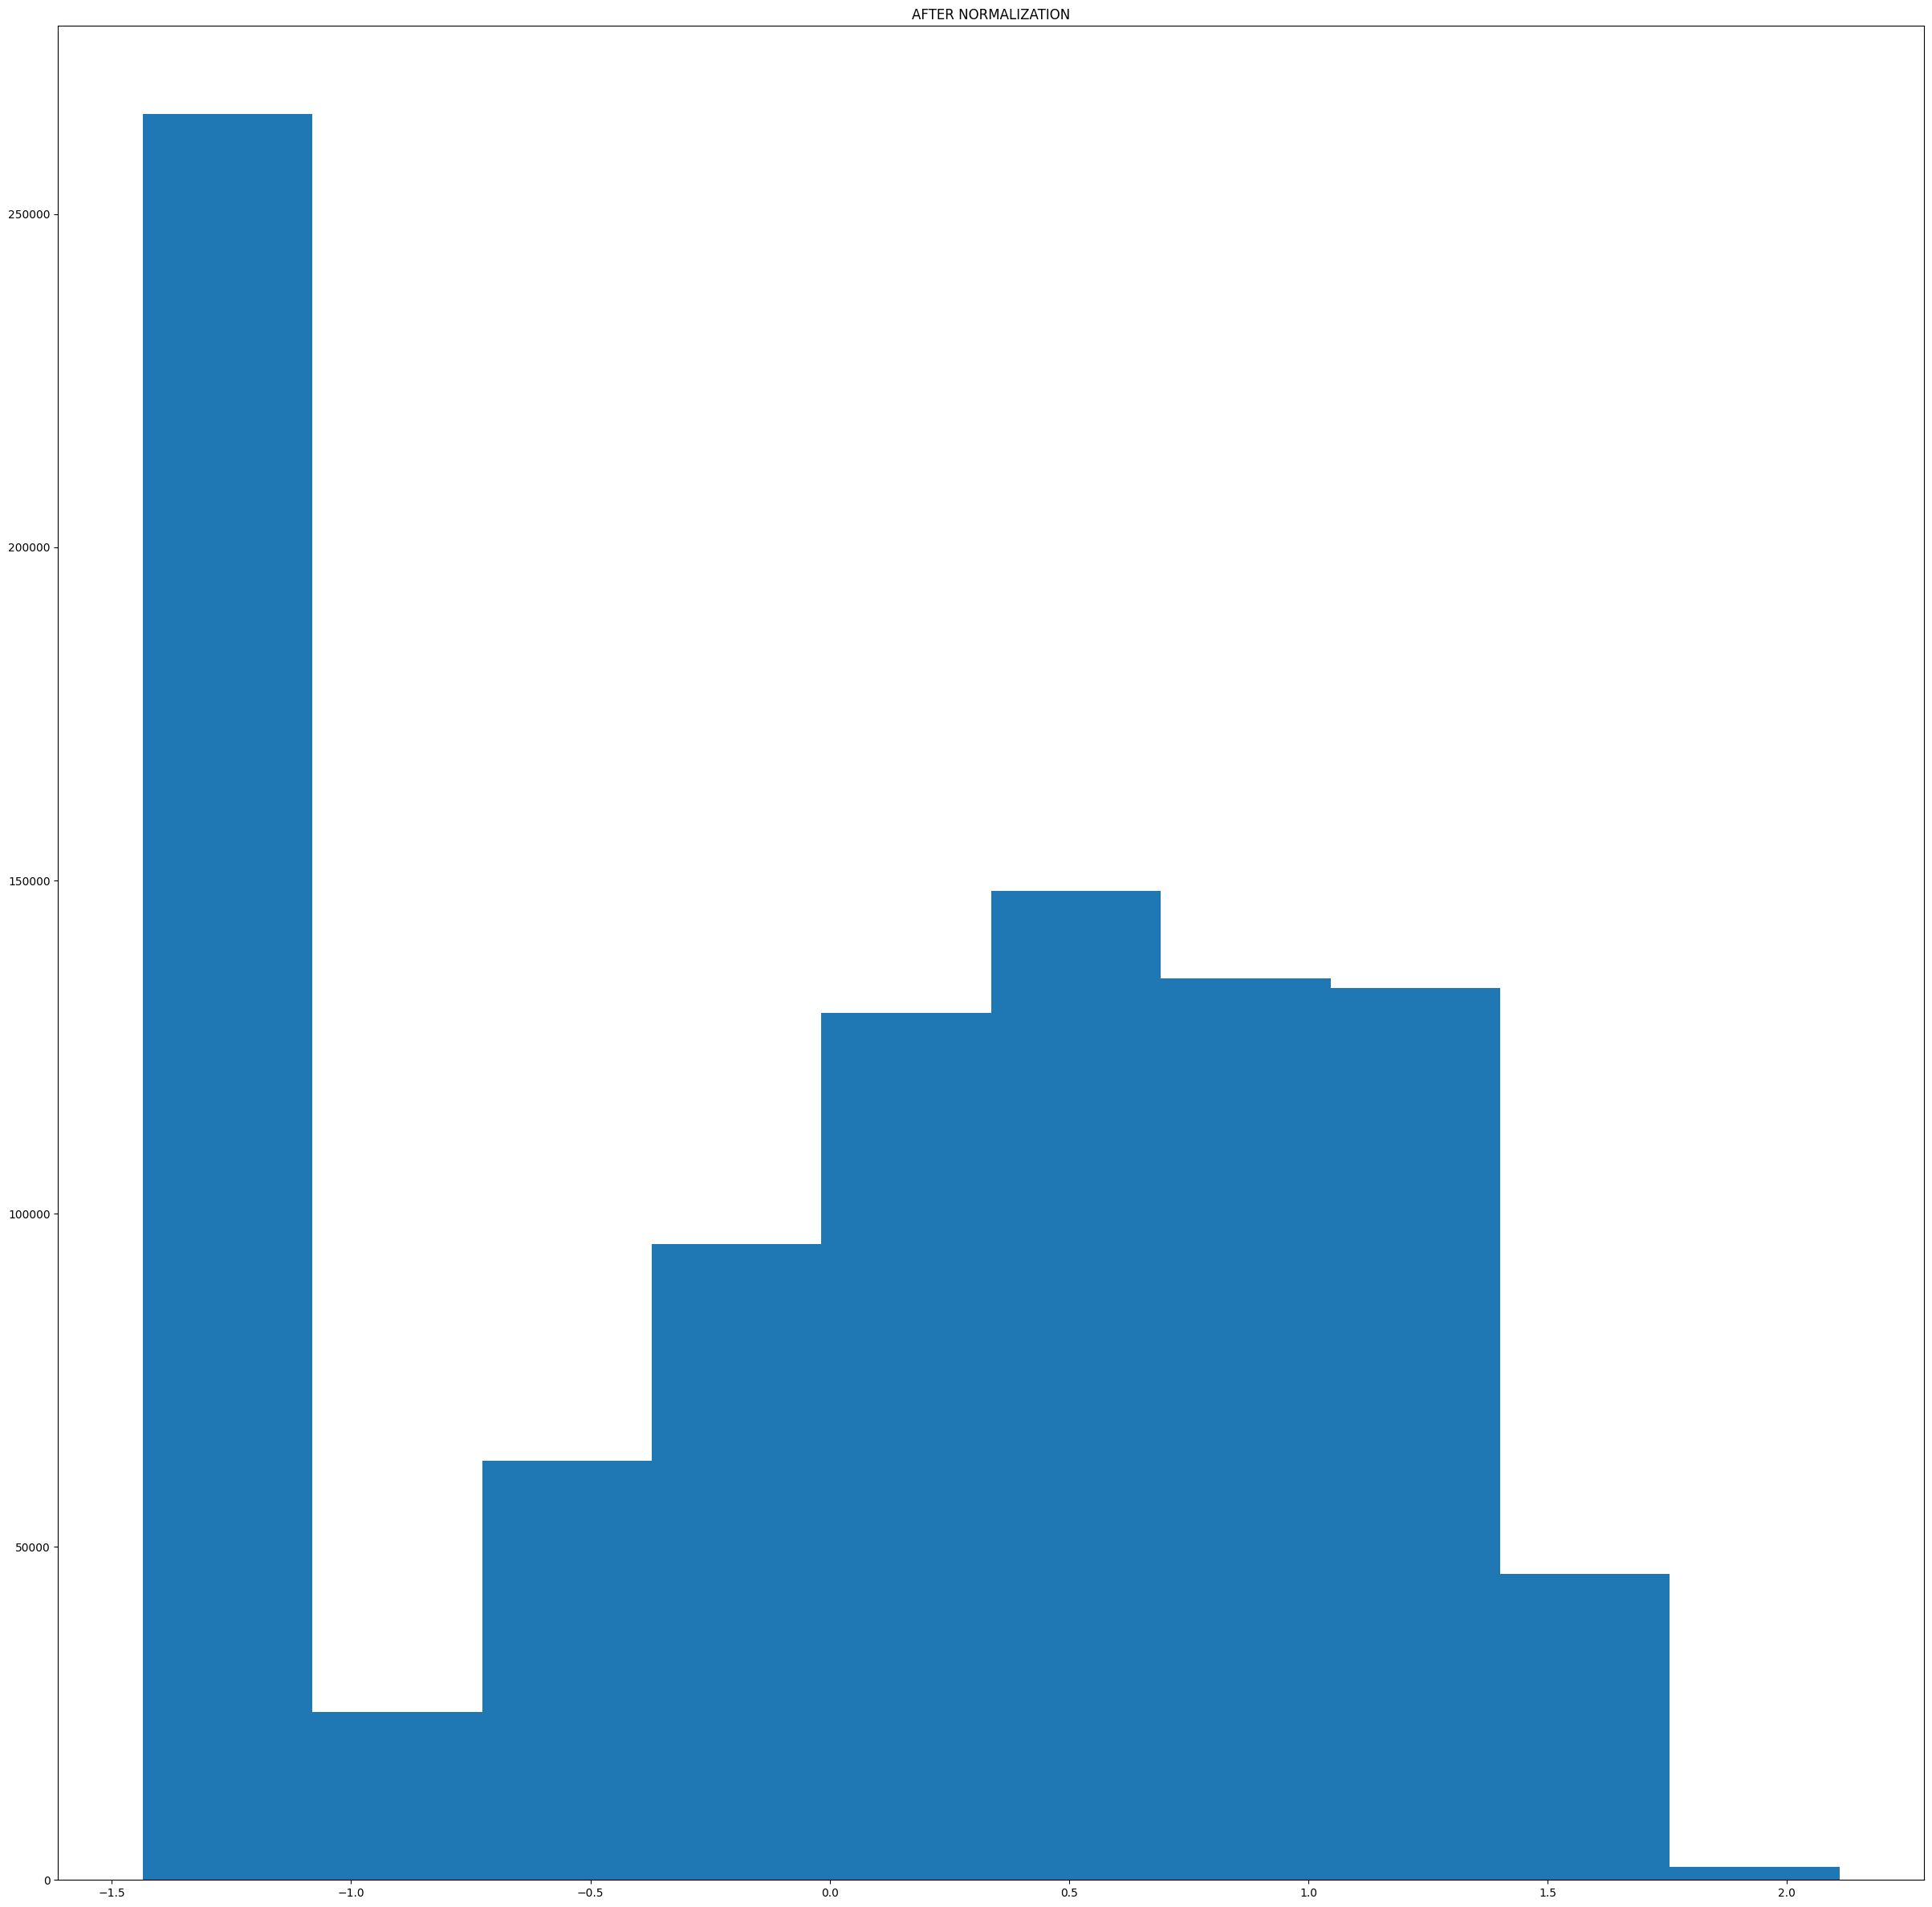

In [ ]:
#NORMALIZAÇÂO POWERTRANSFORMER
from sklearn.preprocessing import PowerTransformer


#box-cox transformation para normalização dos dados
pt_x = PowerTransformer(method='box-cox', standardize=True)

eps=1e-6

#tamanho da janela de treino (train_period-1)+ 1 day target
train_period = 7
Xs, ys = create_sliding_window(X, period=train_period)

#para não ter valores zeros, necessários para box-cox
ys = ys.clamp_min(eps)
Xs[:,:,:,0] = Xs[:,:,:,0].clamp_min(eps)

#print(ys.min())

num_samples = Xs.shape[0]

n_train = int(0.7 * num_samples)
n_val   = int(0.2 * num_samples)
n_test  = num_samples - n_train - n_val

#separação de train/validation/test data
X_train, y_train = Xs[:n_train], ys[:n_train]
X_val,   y_val   = Xs[n_train:n_train+n_val], ys[n_train:n_train+n_val]
X_test,  y_test  = Xs[n_train+n_val:], ys[n_train+n_val:]



xtr = X_train[:,:,:,0].reshape(-1,1).numpy()
xva = X_val[:,:,:,0].reshape(-1,1).numpy()
xte = X_test[:,:,:,0].reshape(-1,1).numpy()

ytr = y_train.reshape(-1,1).numpy()
yva = y_val.reshape(-1,1).numpy()
yte = y_test.reshape(-1,1).numpy()

pt_x.fit(xtr)

X_train[:,:,:,0] = torch.tensor(pt_x.transform(xtr).reshape(X_train[:,:,:,0].shape), dtype=torch.float32)
X_val[:,:,:,0]   = torch.tensor(pt_x.transform(xva).reshape(X_val[:,:,:,0].shape), dtype=torch.float32)
X_test[:,:,:,0]  = torch.tensor(pt_x.transform(xte).reshape(X_test[:,:,:,0].shape), dtype=torch.float32)
y_train = torch.tensor(pt_x.transform(ytr).reshape(y_train.shape), dtype=torch.float32)
y_val = torch.tensor(pt_x.transform(yva).reshape(y_val.shape), dtype=torch.float32)
y_test = torch.tensor(pt_x.transform(yte).reshape(y_test.shape), dtype=torch.float32)

assert_finite("Xs", Xs)
assert_finite("ys", ys)

print("Xs:", tuple(Xs.shape), "ys:", tuple(ys.shape))
print("train/val/test:", n_train, n_val, n_test)

#plt.figure(figsize=(30,30))
#plt.title("AFTER NORMALIZATION")
#plt.hist(X_train[:,:,:,0].reshape(-1,1))
#plt.show()



Xs: (4015, 2, 62, 8) ys: (4015, 62)
train/val/test: 2810 803 402


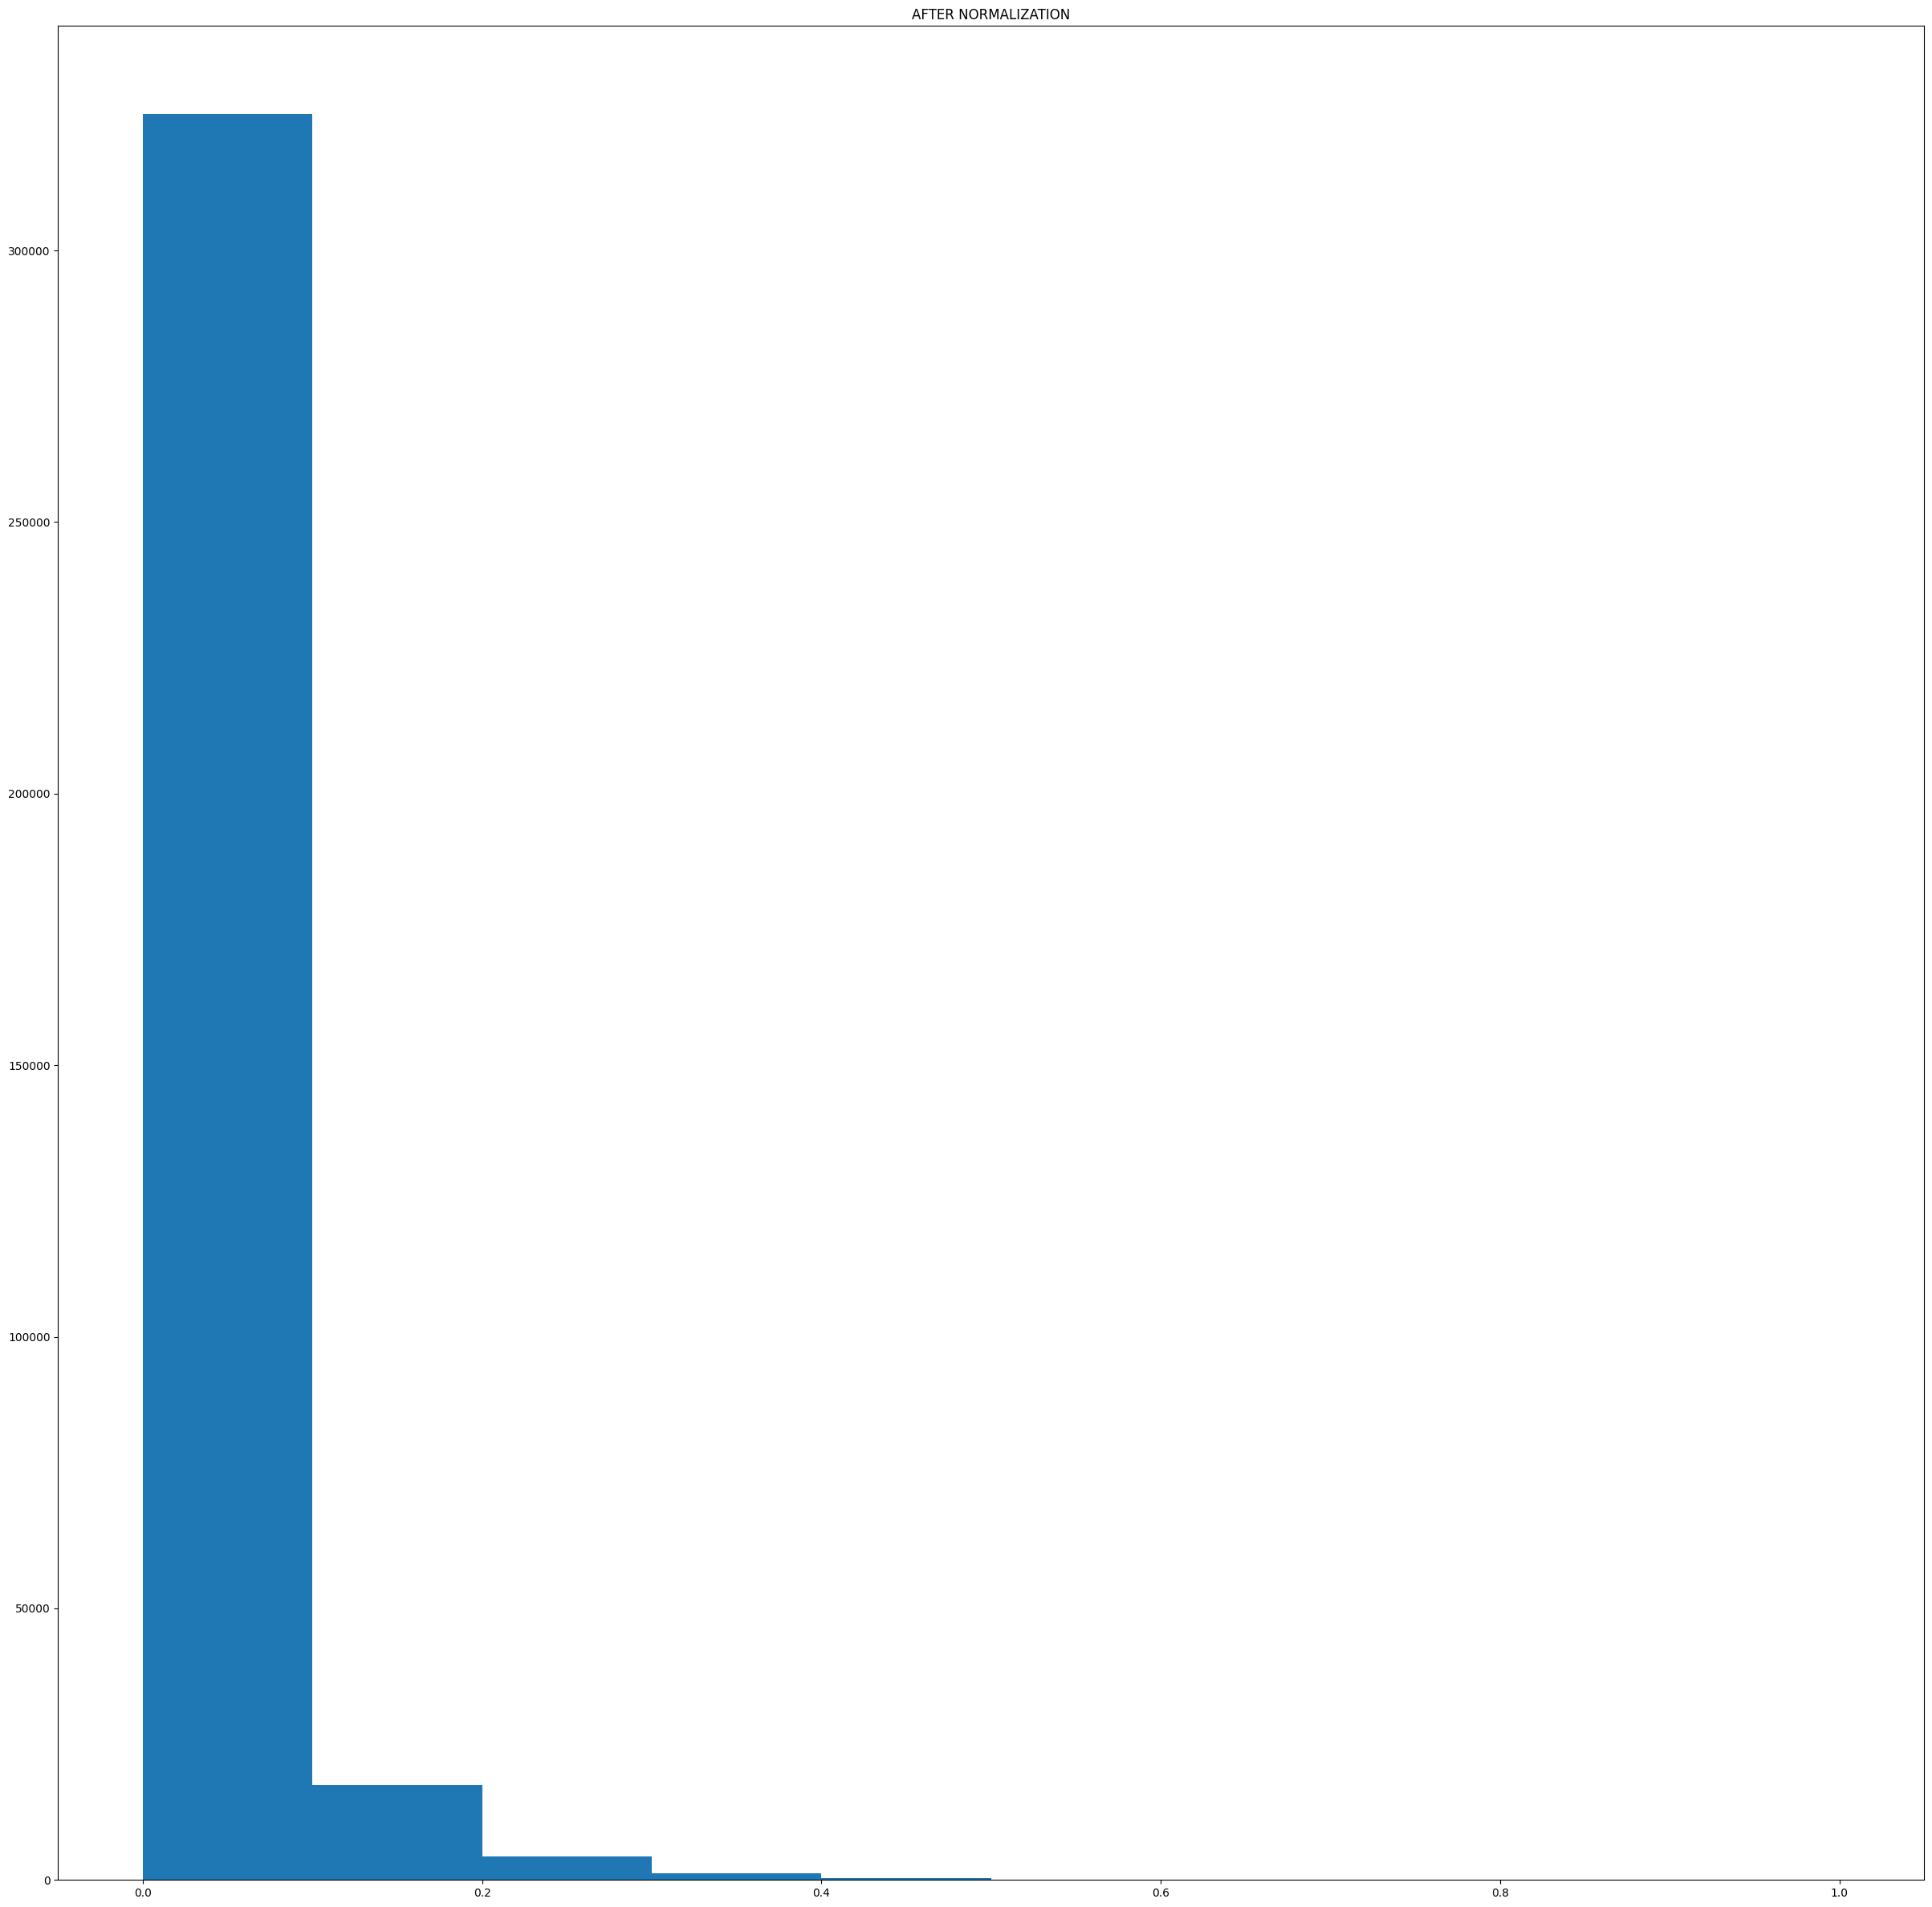

In [ ]:
#MIN-MAX SCALER NORMALIZATION FOR PRECIPITATION
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler

pt_x = MinMaxScaler((0,1))

xtr = X_train[:,:,:,0].reshape(-1,1).numpy()
xva = X_val[:,:,:,0].reshape(-1,1).numpy()
xte = X_test[:,:,:,0].reshape(-1,1).numpy()

ytr = y_train.reshape(-1,1).numpy()
yva = y_val.reshape(-1,1).numpy()
yte = y_test.reshape(-1,1).numpy()

pt_x.fit(xtr)

X_train[:,:,:,0] = torch.tensor(pt_x.transform(xtr).reshape(X_train[:,:,:,0].shape), dtype=torch.float32)
X_val[:,:,:,0]   = torch.tensor(pt_x.transform(xva).reshape(X_val[:,:,:,0].shape), dtype=torch.float32)
X_test[:,:,:,0]  = torch.tensor(pt_x.transform(xte).reshape(X_test[:,:,:,0].shape), dtype=torch.float32)
y_train = torch.tensor(pt_x.transform(ytr).reshape(y_train.shape), dtype=torch.float32)
y_val = torch.tensor(pt_x.transform(yva).reshape(y_val.shape), dtype=torch.float32)
y_test = torch.tensor(pt_x.transform(yte).reshape(y_test.shape), dtype=torch.float32)

assert_finite("Xs", Xs)
assert_finite("ys", ys)

print("Xs:", tuple(Xs.shape), "ys:", tuple(ys.shape))
print("train/val/test:", n_train, n_val, n_test)

#plt.figure(figsize=(30,30))
#plt.title("AFTER NORMALIZATION")
#plt.hist(X_train[:,:,:,0].reshape(-1,1))
#plt.show()



In [46]:
#NO PRECIPITATION SCALE
from sklearn.preprocessing import MinMaxScaler
scaler_1 = MinMaxScaler((-1,1))
scaler_2 = MinMaxScaler((-1,1))

train_period = 7
Xs, ys = create_sliding_window(X, period=train_period)
ys = ys.clamp_min(0.0)

Xs[:,:,14:20] = torch.tensor(scaler_1.fit_transform(Xs[:,:,14:20].reshape(-1,1))).reshape(Xs[:,:,14:20].shape)

num_samples = Xs.shape[0]

n_train = int(0.7 * num_samples)
n_val   = int(0.2 * num_samples)
n_test  = num_samples - n_train - n_val


X_train, y_train = Xs[:n_train], ys[:n_train]
X_val,   y_val   = Xs[n_train:n_train+n_val], ys[n_train:n_train+n_val]
X_test,  y_test  = Xs[n_train+n_val:], ys[n_train+n_val:]

#pt = PowerTransformer(method='box-cox', standardize=True)

#X_train[:,:,0], y_train[:,:] = pt.fit(X_train[:,:,0].reshape(num_samples, N)), pt.fit(y_train[:,:])





#Normalização pela log(1+x) e depois z-score

#var, mean, std = normalize_tp(Xs[:n_train, :, :, 0])
#Xs[:n_train, :, :, 0] = var
#ys = (torch.log1p(ys) - mean) / std

assert_finite("Xs", Xs)
assert_finite("ys", ys)

print("Xs:", tuple(Xs.shape), "ys:", tuple(ys.shape))
print("train/val/test:", n_train, n_val, n_test)


Xs: (4011, 6, 62, 32) ys: (4011, 62)
train/val/test: 2807 802 402


In [ ]:
# Normaliza os 12 canais de velocidade vertical (features 1..12) USANDO Z-SCORE
# usando somente estatísticas do treino.
# Formato esperado: Xs = [samples, T, N, F]

eps = 1e-6
vv_idx = slice(1, 13)  # 12 features de vv

# estatísticas no treino
vv_train = Xs[:n_train, :, :, vv_idx]
vv_mean = vv_train.mean(dim=(0, 1, 2), keepdim=True)              # [1,1,1,12]
vv_std = vv_train.std(dim=(0, 1, 2), keepdim=True).clamp_min(eps) # [1,1,1,12]

# aplica em treino/val/test com as mesmas stats
Xs[:, :, :, vv_idx] = (Xs[:, :, :, vv_idx] - vv_mean) / vv_std

# checagem
assert torch.isfinite(Xs[:, :, :, vv_idx]).all(), "NaN/Inf após normalização de vv"

# opcional: salvar stats para reuso/inferência
vv_norm_stats = {"vv_mean": vv_mean.cpu(), "vv_std": vv_std.cpu()}


In [456]:
from sklearn.preprocessing import StandardScaler
scaler_list = {}
for j in range(8,20):
    scaler = StandardScaler()
    xtr = X_train[...,j].reshape(-1,1).numpy()
    xva = X_val[...,j].reshape(-1,1).numpy()
    xte = X_test[...,j].reshape(-1,1).numpy()
    scaler.fit(xtr)
    X_train[...,j] = torch.tensor(scaler.transform(xtr).reshape(X_train[...,j].shape))
    X_val[...,j]   = torch.tensor(scaler.transform(xva).reshape(X_val[...,j].shape))
    X_test[...,j]  = torch.tensor(scaler.transform(xte).reshape(X_test[...,j].shape))
    
    

tensor(0.8903) tensor(-1.0388)


(array([3.000000e+01, 6.700000e+01, 2.240000e+02, 1.070000e+03,
        1.004300e+04, 1.330540e+05, 6.432781e+06, 5.947421e+06,
        5.650000e+03, 1.080000e+02]),
 array([-1.        , -0.80000001, -0.60000002, -0.39999998, -0.19999999,
         0.        ,  0.20000005,  0.39999998,  0.60000002,  0.80000007,
         0.99999994]),
 <BarContainer object of 10 artists>)

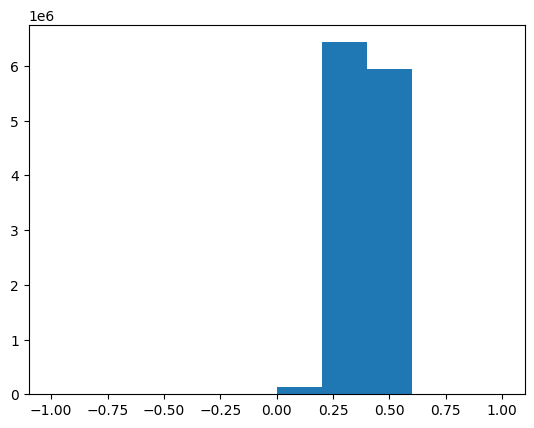

In [ ]:
# Normaliza os 12 canais de velocidade vertical (features 1..12) USANDO MIN-MAX SCALER
# usando somente estatísticas do treino.
# Formato esperado: Xs = [samples, T, N, F]

scaler_vv = MinMaxScaler((-1,1))

for j in range(vv_idx):
    #xtr = X_train[...,j]
    print(j)

vv_idx = slice(8,20)  # 12 features de vv

xtr = X_train[...,vv_idx].reshape(-1,1).numpy()
xva = X_val[...,vv_idx].reshape(-1,1).numpy()
xte = X_test[..., vv_idx].reshape(-1,1).numpy()


scaler_vv.fit(xtr)

X_train[...,vv_idx] = torch.tensor(scaler_vv.transform(xtr).reshape(X_train[...,vv_idx].shape))
X_val[...,vv_idx]   = torch.tensor(scaler_vv.transform(xva).reshape(X_val[...,vv_idx].shape))
X_test[...,vv_idx]  = torch.tensor(scaler_vv.transform(xte).reshape(X_test[...,vv_idx].shape))




# checagem
assert torch.isfinite(Xs[..., vv_idx]).all(), "NaN/Inf após normalização de vv"
print(X_val[...,vv_idx].max(), X_val[...,vv_idx].min())

plt.hist(X_train[...,vv_idx].flatten())



In [457]:
# Normaliza os canais de temperatura e dewpoint USANDO MIN-MAX SCALER
# usando somente estatísticas do treino.
# Formato esperado: Xs = [samples, T, N, F]
from sklearn.preprocessing import MinMaxScaler
scaler_temp = MinMaxScaler((-1,1))
scaler_dew = MinMaxScaler((-1,1))


temp_idx = slice(2,5)  # 12 features de temperatura
dew_idx = slice(5,8)

xtr_temp = X_train[...,temp_idx].reshape(-1,1).numpy()
xva_temp = X_val[...,temp_idx].reshape(-1,1).numpy()
xte_temp = X_test[..., temp_idx].reshape(-1,1).numpy()
xtr_dew = X_train[...,dew_idx].reshape(-1,1).numpy()
xva_dew = X_val[...,dew_idx].reshape(-1,1).numpy()
xte_dew = X_test[..., dew_idx].reshape(-1,1).numpy()


scaler_temp.fit(xtr_temp)
scaler_dew.fit(xtr_dew)

X_train[...,temp_idx] = torch.tensor(scaler_temp.transform(xtr_temp).reshape(X_train[...,temp_idx].shape))
X_val[...,temp_idx]   = torch.tensor(scaler_temp.transform(xva_temp).reshape(X_val[...,temp_idx].shape))
X_test[...,temp_idx]  = torch.tensor(scaler_temp.transform(xte_temp).reshape(X_test[...,temp_idx].shape))

X_train[...,dew_idx] = torch.tensor(scaler_dew.transform(xtr_dew).reshape(X_train[...,dew_idx].shape))
X_val[...,dew_idx]   = torch.tensor(scaler_dew.transform(xva_dew).reshape(X_val[...,dew_idx].shape))
X_test[...,dew_idx]  = torch.tensor(scaler_dew.transform(xte_dew).reshape(X_test[...,dew_idx].shape))




# checagem
#assert torch.isfinite(Xs[..., temp_idx]).all(), "NaN/Inf após normalização de vv"

(array([[1.370800e+04, 1.679540e+05, 7.058800e+05, 1.944005e+06,
         3.605434e+06, 4.166547e+06, 2.832147e+06, 1.242746e+06,
         3.468560e+05, 2.937700e+04],
        [2.262000e+03, 5.199400e+04, 2.794730e+05, 8.079340e+05,
         1.764867e+06, 3.197977e+06, 4.151894e+06, 3.492193e+06,
         1.250680e+06, 5.538000e+04]]),
 array([-1.        , -0.80000001, -0.60000002, -0.39999998, -0.19999999,
         0.        ,  0.20000005,  0.39999998,  0.60000002,  0.80000007,
         1.        ]),
 <a list of 2 BarContainer objects>)

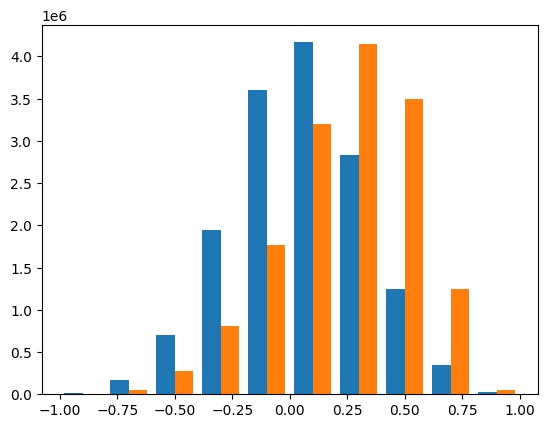

In [458]:
plt.hist([X_train[...,temp_idx].flatten(), X_train[...,dew_idx].flatten()])

In [459]:
# Normaliza os canais de vento USANDO MIN-MAX SCALER
# usando somente estatísticas do treino.
# Formato esperado: Xs = [samples, T, N, F]

scaler_wind = MinMaxScaler((-1,1))


wind_idx = slice(16,32)  # 16 fetures of wind

xtr = X_train[...,wind_idx].reshape(-1,1).numpy()
xva = X_val[...,wind_idx].reshape(-1,1).numpy()
xte = X_test[..., wind_idx].reshape(-1,1).numpy()


scaler_wind.fit(xtr)

X_train[...,wind_idx] = torch.tensor(scaler_wind.transform(xtr).reshape(X_train[...,wind_idx].shape))
X_val[...,wind_idx]   = torch.tensor(scaler_wind.transform(xva).reshape(X_val[...,wind_idx].shape))
X_test[...,wind_idx]  = torch.tensor(scaler_wind.transform(xte).reshape(X_test[...,wind_idx].shape))




# checagem
assert torch.isfinite(Xs[..., wind_idx]).all(), "NaN/Inf após normalização de wind"

#plt.hist([X_train[...,wind_idx].flatten(), X_train[...,wind_idx].flatten()])

In [460]:
# Train/val split and DataLoaders

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

pin_memory = (device == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

train batches: 175 val batches: 50 test batches: 25


In [461]:
# Graph + model
from torch_geometric.nn.conv import GCNConv, ChebConv

edge_index, edge_weight = grafo_distancias(stations=estacoes_RS, criterion=criterion_km)
edge_index = edge_index.to(device)

class GLSTMCellBatch(nn.Module):
    def __init__(self, N, input_size, hidden_size, edge_index, edge_weight=None, learn_adj=True):
        super().__init__()
        self.edge_index = edge_index
        self.learn_adj = learn_adj
        
        
        if edge_weight is None and learn_adj==True:
            self.edge_weight = torch.ones(edge_index.shape[1])
        
        if edge_weight is None and learn_adj==False:
            self.edge_weight = None
            
        else:
            self.edge_weight = self.edge_weight
            


        if learn_adj:
            self.A = nn.Parameter(adjacency_matrix(N, edge_index, self.edge_weight))
        else:
            self.A = adjacency_matrix(N, edge_index, self.edge_weight)
            
        """
        else:
            self.gcn_h = GCNConv(hidden_size, hidden_size)
            self.gcn_c = GCNConv(hidden_size, hidden_size)
        """


        self.W_i = nn.Linear(input_size, hidden_size).to(device)
        self.W_f = nn.Linear(input_size, hidden_size).to(device)
        self.W_o = nn.Linear(input_size, hidden_size).to(device)
        self.W_u = nn.Linear(input_size, hidden_size).to(device)

        self.U_i = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_f = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_o = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_u = nn.Linear(hidden_size, hidden_size).to(device)

    def forward(self, X, H_prev, C_prev):
        # X: [B, N, F], H/C: [B, H, N]
        if self.learn_adj:
            
            #A_eff = self.A
            #self.A = nn.Parameter(self.A+self.A.T)
            #A_raw = self.A
            #A_pos = F.softplus(A_raw)
            #A_eff = A_pos / (A_pos.sum(dim=1, keepdim=True)+1e-6)
  
                    
            H_graph = torch.einsum("bhm,mn->bhn", H_prev, self.A).to(device)
            C_graph = torch.einsum("bhm,mn->bhn", C_prev, self.A).to(device)


            Hg = H_graph.permute(0, 2, 1).to(device)
            Hp = H_prev.permute(0, 2, 1).to(device)
        else:
            A_eff = self.A
            
            H_graph = torch.einsum("bhm,mn->bhn", H_prev, A_eff).to(device)
            C_graph = torch.einsum("bhm,mn->bhn", C_prev, A_eff).to(device)


            Hg = H_graph.permute(0, 2, 1).to(device)
            Hp = H_prev.permute(0, 2, 1).to(device)
            
       
        Xp = X.to(device)

        I = torch.sigmoid(self.W_i(Xp) + self.U_i(Hg)).permute(0, 2, 1)
        Fg = torch.sigmoid(self.W_f(Xp) + self.U_f(Hp)).permute(0, 2, 1)
        O = torch.sigmoid(self.W_o(Xp) + self.U_o(Hg)).permute(0, 2, 1)
        U = torch.tanh(self.W_u(Xp) + self.U_u(Hg)).permute(0, 2, 1)

        C_t = I * U + Fg * C_graph
        H_t = O * torch.tanh(C_t)
        return C_t, H_t


class GLSTMBatch(nn.Module):
    def __init__(self, N, edge_index, in_channels, hidden_size, out_channels=1, learn_adj=True):
        super().__init__()
        self.N = N
        self.hidden_size = hidden_size
        self.cell = GLSTMCellBatch(N, in_channels, hidden_size, edge_index, learn_adj=learn_adj)
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 1)
            
            #nn.Softplus(beta=0.5),
            #nn.Linear(hidden_size, hidden_size),
            #nn.Softplus(beta=0.5),
            #nn.Linear(hidden_size, hidden_size//2),
            #nn.Softplus(beta=0.5),
            #nn.Linear(hidden_size//2, out_channels)
            #nn.ReLU(),
            #nn.Linear(hidden_size//4, out_channels)
            #nn.Sigmoid()
        ).to(device)

    def forward(self, x_seq):
        #print(x_seq.shape)
        # x_seq: [B, T, N, F]
        B, T, _, _ = x_seq.shape
        H = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
        C = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)

        for t in range(T):
            C, H = self.cell(x_seq[:, t], H, C)
            #print(C.norm(), H.norm())
        out = H.permute(0, 2, 1).to(device)  # [B, N, H]
        return self.fc(out).squeeze(-1)  # [B, N]


In [467]:
# Training routines (no benchmark)

loss_fn = nn.MSELoss()

def eval_with_loader(model, loader, use_amp, amp_device, amp_dtype):
    model.eval()
    total_loss, total_mse, total_mae, total_mape, total_r2 = 0.0, 0.0, 0.0, 0.0, 0.0
    steps = 0
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"eval_xb_batch{batch_idx}", xb)
            assert_finite(f"eval_yb_batch{batch_idx}", yb)

            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"eval_pred_batch{batch_idx}", pred)
                loss = loss_fn(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite eval loss on batch={batch_idx}")

            total_loss += loss.item()
            total_mse += mse_fn(pred, yb).item()
            total_mae += mae_fn(pred, yb).item()
            total_mape += safe_mape(yb, pred, eps=1e-3).item()
            total_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

    return {
        "loss": total_loss / max(steps, 1),
        "mse": total_mse / max(steps, 1),
        "mae": total_mae / max(steps, 1),
        "mape": total_mape / max(steps, 1),
        "r2": total_r2 / max(steps, 1),
    }


def train_batched_only(model, train_loader, val_loader, train_period, hidden_dim, epochs, lr, weight_decay, patience, run_dir=None):
    model = copy.deepcopy(model).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    # Estável para debug: AMP desligado
    use_amp = False
    amp_device = "cuda"
    amp_dtype = torch.float16
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    print(f"train_batched_only: use_amp={use_amp}")

    best_model = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    counter = 0

    history = {
        "train_loss": [], "train_mse": [], "train_mae": [], "train_mape": [], "train_r2": [],
        "val_loss": [], "val_mse": [], "val_mae": [], "val_mape": [], "val_r2": [], "epoch_time": []
    }

    for ep in range(epochs):
        t0 = time.perf_counter()
        model.train()
        train_loss = 0.0
        train_mse = 0.0
        train_mae = 0.0
        train_mape = 0.0
        train_r2 = 0.0
        steps = 0

        for batch_idx, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"train_xb_epoch{ep}_batch{batch_idx}", xb)
            assert_finite(f"train_yb_epoch{ep}_batch{batch_idx}", yb)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"train_pred_epoch{ep}_batch{batch_idx}", pred)
                loss = loss_fn(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite loss epoch={ep} batch={batch_idx}")

            scaler.scale(loss).backward()
            
            

            for name, param in model.named_parameters():
                #if param.grad is not None:
                    #print(name, param.grad.abs().mean())
                if param.grad is not None and (not torch.isfinite(param.grad).all()):
                    raise RuntimeError(f"non-finite gradient in {name} epoch={ep} batch={batch_idx}")

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.8)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_mse += mse_fn(pred, yb).item()
            train_mae += mae_fn(pred, yb).item()
            train_mape += safe_mape(yb, pred, eps=1e-3).item()
            train_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

        history["train_loss"].append(train_loss / max(steps, 1))
        history["train_mse"].append(train_mse / max(steps, 1))
        history["train_mae"].append(train_mae / max(steps, 1))
        history["train_mape"].append(train_mape / max(steps, 1))
        history["train_r2"].append(train_r2 / max(steps, 1))

        val_metrics = eval_with_loader(model, val_loader, use_amp, amp_device, amp_dtype)
        history["val_loss"].append(val_metrics["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_mape"].append(val_metrics["mape"])
        history["val_r2"].append(val_metrics["r2"])

        history["epoch_time"].append(time.perf_counter() - t0)

        print(
            f"epoch={ep+1}/{epochs}" 
            f"train_loss={history['train_loss'][-1]:e}/"
            f"val_loss={history['val_loss'][-1]:e}/"
            f"train_mae={history['train_mae'][-1]:e}/"
            f"val_mae={history['val_mae'][-1]:e}/" 
            f"val_mape={history['val_mape'][-1]:e}/"
            f"val_r2={history['val_r2'][-1]:e}"
        )

        if history["val_loss"][-1] < best_val_loss:
            best_val_loss = history["val_loss"][-1]
            counter = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            counter += 1

        if counter > patience:
            model.load_state_dict(best_model)
            print("Early Stopping")
            break

    model.load_state_dict(best_model)

    summary = {
        "hiddem_dim"        : hidden_dim,
        'train_period'      : train_period,
        "device"            : device,
        "epochs_requested"  : epochs,
        "epochs_ran"        : len(history["epoch_time"]),
        "lr"                : lr,
        "weight_decay"      : weight_decay,
        "patience"          : patience,
        "batch_size"        : train_loader.batch_size,
        "best_val_loss"     : best_val_loss,
        "last_val_mse"      : history["val_mse"][-1] if history["val_mse"] else None,
        "last_val_mae"      : history["val_mae"][-1] if history["val_mae"] else None,
        "last_val_mape"     : history["val_mape"][-1] if history["val_mape"] else None,
        "last_val_r2"       : history["val_r2"][-1] if history["val_r2"] else None,
        "total_time_s"      : float(sum(history["epoch_time"])),
    }

    if run_dir is not None:
        run_dir = Path(run_dir)
        run_dir.mkdir(parents=True, exist_ok=True)

        save_error_plots(
            str(run_dir),
            history["train_mse"], history["val_mse"],
            history["train_mae"], history["val_mae"],
            history["train_r2"],  history["val_r2"],
        )

        torch.save(history, run_dir / "hist.pt")
        torch.save(model.state_dict(), run_dir / "model_state_dict.pt")
        with open(run_dir / "run_summary.json", "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)

    return model, history, summary


In [463]:
#funções de plots necessárias

def plot_estacao_unica(y_real, y_pred, station_idx, start_date_plot, station_name=None):
    """
    y_real, y_pred: tensores [T, N] (escala física, ex: mm/dia)
    station_idx: índice do nó/estação
    start_date_plot: ex. "2025-01-01"
    """
    y_real_np = y_real[:, station_idx].detach().cpu().numpy()
    y_pred_np = y_pred[:, station_idx].detach().cpu().numpy()
    datas = pd.date_range(start=start_date_plot, periods=len(y_real_np), freq="D")

    plt.figure(figsize=(12, 4))
    plt.plot(datas, y_real_np, label="ERA5 real", linewidth=2)
    plt.plot(datas, y_pred_np, label="Rede estimado", linewidth=2)
    plt.title(f"Real vs Previsto - nó {station_idx}" if station_name is None else f"Real vs Previsto - {station_name}")
    plt.xlabel("Data")
    plt.ylabel("Precipitação")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def prever_futuro_precip_todos_nos(
    model,
    X_hist_ready,              # [T_hist, N, F] já no mesmo pré-processamento do treino
    horizon,                   # número de dias/passos futuros
    train_period,              # mesmo train_period usado no treino
    future_exog_ready=None,    # [horizon, N, F] (opcional). Se None, replica último passo
    target_col=0,              # coluna da precipitação nas features
    device=None,
    inverse_transformer=None,  # ex: pt_x (PowerTransformer), opcional
):
    """
    Retorna:
      pred_scaled: [horizon, N] na escala do modelo
      pred_real:   [horizon, N] em escala física (se inverse_transformer for fornecido), senão None
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    n_in = model.cell.W_i.in_features
    seq_len = train_period - 1

    if X_hist_ready.ndim != 3:
        raise ValueError("X_hist_ready deve ter shape [T_hist, N, F].")
    if X_hist_ready.shape[0] < seq_len:
        raise ValueError(f"Histórico insuficiente: precisa de pelo menos {seq_len} passos.")
    if future_exog_ready is not None and future_exog_ready.shape[0] < horizon:
        raise ValueError("future_exog_ready tem menos passos que horizon.")

    X_hist_ready = X_hist_ready[:, :, :n_in].float().cpu()
    if future_exog_ready is not None:
        future_exog_ready = future_exog_ready[:, :, :n_in].float().cpu()

    window = X_hist_ready[-seq_len:].clone()  # [seq_len, N, F]
    preds = []

    with torch.no_grad():
        for h in range(horizon):
            y_hat = model(window.unsqueeze(0).to(device)).squeeze(0).detach().cpu()  # [N]
            preds.append(y_hat)
            next_step = window[-1].clone() if future_exog_ready is None else future_exog_ready[h].clone()
            next_step[:, target_col] = y_hat  # autoregressivo
            window = torch.cat([window[1:], next_step.unsqueeze(0)], dim=0)

    pred_scaled = torch.sack(preds, dim=0)  # [horizon, N]

    pred_real = None
    if inverse_transformer is not None:
        arr = pred_scaled.numpy().reshape(-1, 1)
        inv = inverse_transformer.inverse_transform(arr).reshape(pred_scaled.shape)
        pred_real = torch.tensor(inv, dtype=torch.float32)

    return pred_scaled, pred_real

In [464]:
def combined_loss(y_pred, y_true,alpha=0.5):
    mse = nn.MSELoss()
    mae = nn.L1Loss()
    return alpha*mse(y_pred, y_true)+(1-alpha)*mae(y_pred, y_true)

In [ ]:
edge_index = edge_index_knn.to(device)
loss_fn = nn.MSELoss()


for lr in [1e-2, 1e-3, 1e-4]:
    for hidden_dim in [32, 64, 128, 256]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatch(N=N, edge_index=edge_index, in_channels=32, hidden_size=hidden_dim,
                            out_channels=1, learn_adj=True)

        model.apply(reset_weights)
        # normaliza A por linha para evitar explosão recorrente

        # m in model.modules():
        #    if hasattr(m, "A"):
        #        with torch.no_grad():
        #            A = torch.nan_to_num(m.A.data, nan=0.0, posinf=1.0, neginf=-1.0)
        #            m.A.data = A / (A.abs().sum(dim=1, keepdim=True) + 1e-6)
                    
        window_folder = f"C:\\Experiments\\multi_model_04_03\\WINDOW_{train_period}"

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            hist = train_batched_only(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=train_period,
                epochs=300, lr=lr, weight_decay=5e-4, patience=35, run_dir=exp_path+f"\\BATCH_TEST_{j}"
            )

========================HIDDEN_DIM: 32=============================
========================ITERATION 0=============================
train_batched_only: use_amp=False
epoch=1/300train_loss=6.410110e-01/val_loss=6.862667e-01/train_mae=6.243052e-01/val_mae=6.407832e-01/val_mape=4.542551e+02/val_r2=-6.265118e-02
epoch=2/300train_loss=6.004486e-01/val_loss=6.102042e-01/train_mae=6.133640e-01/val_mae=6.209073e-01/val_mape=5.052562e+02/val_r2=3.613293e-02
epoch=3/300train_loss=5.462008e-01/val_loss=5.706437e-01/train_mae=5.725076e-01/val_mae=5.929408e-01/val_mape=4.933187e+02/val_r2=9.413568e-02
epoch=4/300train_loss=5.101722e-01/val_loss=5.596231e-01/train_mae=5.383803e-01/val_mae=6.030504e-01/val_mape=5.441050e+02/val_r2=9.897315e-02
epoch=5/300train_loss=4.835818e-01/val_loss=5.629145e-01/train_mae=5.188724e-01/val_mae=6.013852e-01/val_mape=5.359730e+02/val_r2=1.041729e-01
epoch=6/300train_loss=4.760508e-01/val_loss=5.605019e-01/train_mae=5.135299e-01/val_mae=5.958576e-01/val_mape=5.26830

In [ ]:
predict_test = torch.expm1(model(X_test.to(device)).detach())*std+mean
y_test = torch.expm1(y_test).to(device)*std+mean

(array([2.184e+03, 8.811e+03, 8.034e+03, 3.867e+03, 1.442e+03, 4.250e+02,
        1.170e+02, 2.900e+01, 9.000e+00, 6.000e+00]),
 array([-0.02937496,  0.46140549,  0.95218593,  1.44296634,  1.93374681,
         2.42452717,  2.91530752,  3.40608835,  3.89686871,  4.38764906,
         4.87842941]),
 <BarContainer object of 10 artists>)

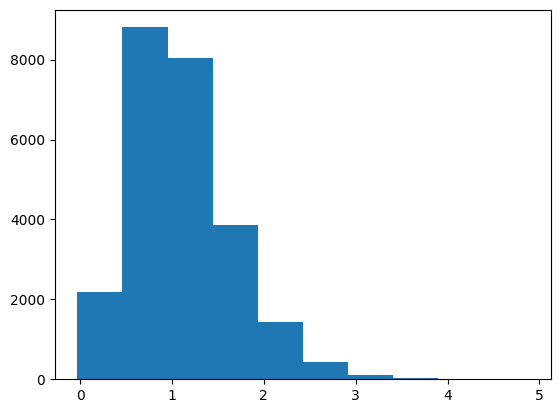

In [414]:
plt.hist(predict_test.detach().cpu().flatten())

tensor(629.4015, device='cuda:0')


In [280]:
y_scaled, y_real = future_prediction(model,
                                     X_hist_ready=X_test[-1],
                                     horizon=5,
                                     train_period=train_period
                                     )

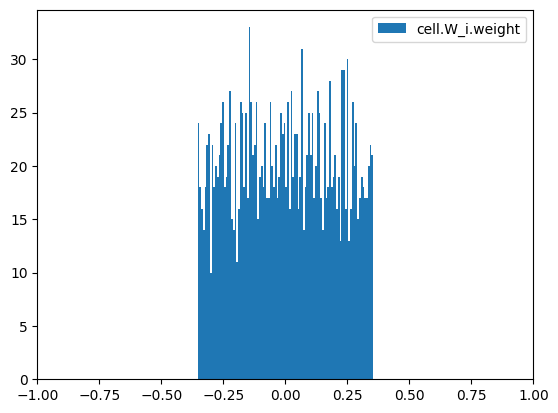

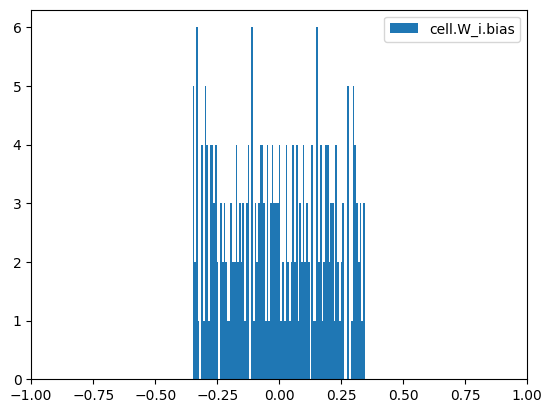

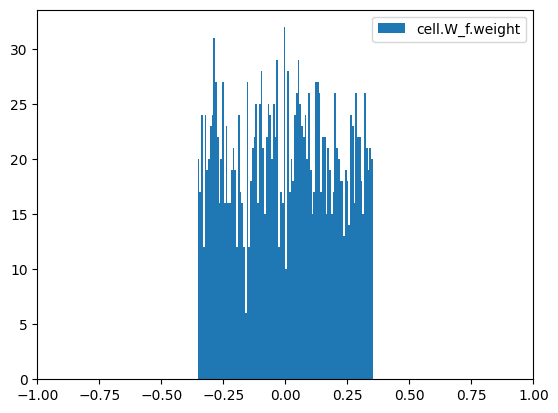

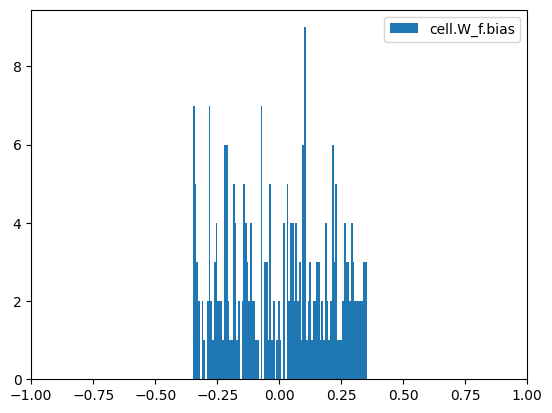

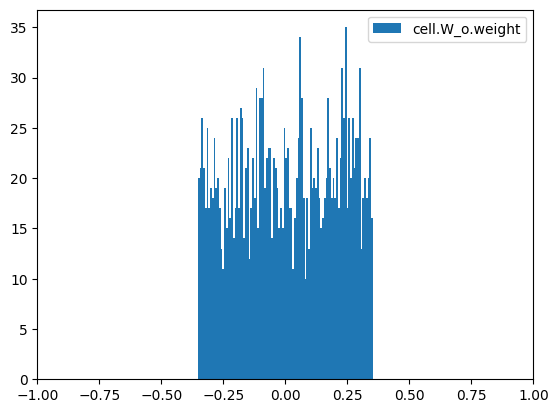

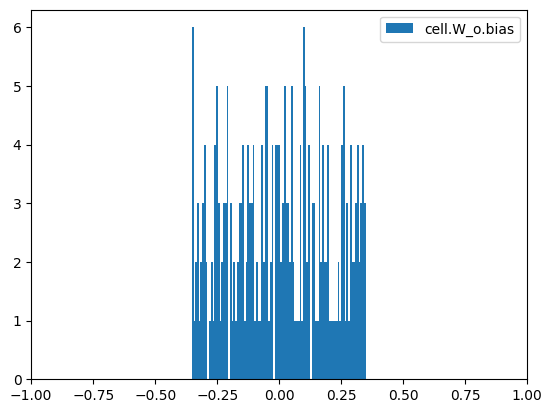

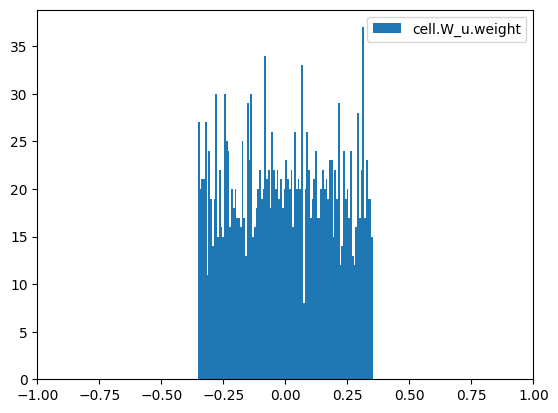

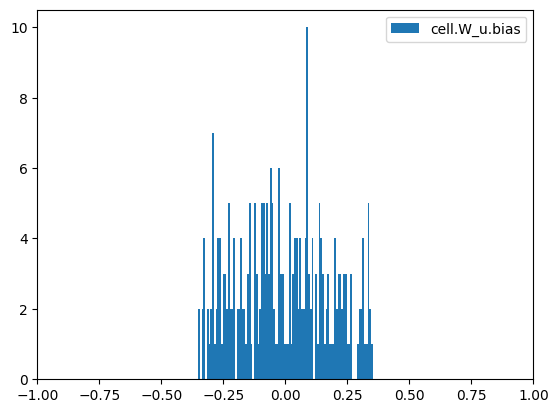

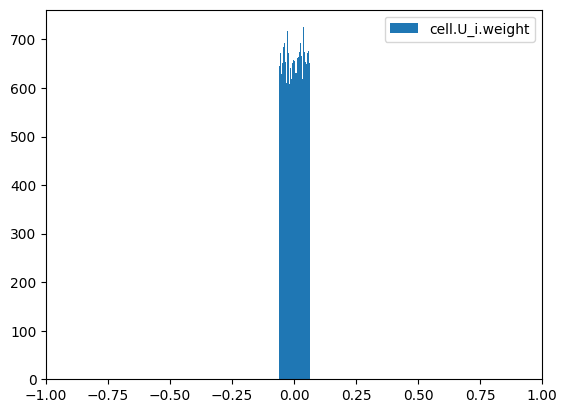

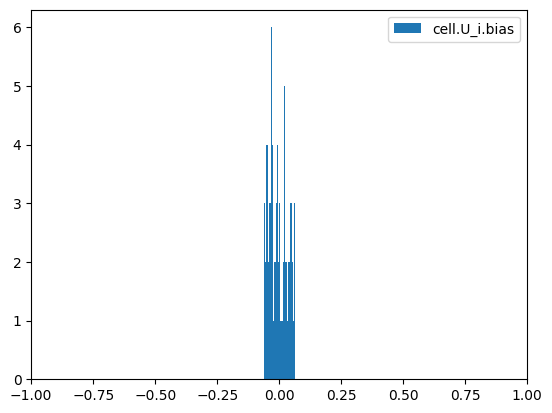

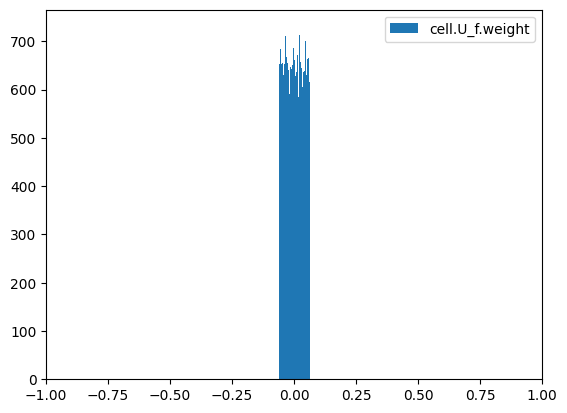

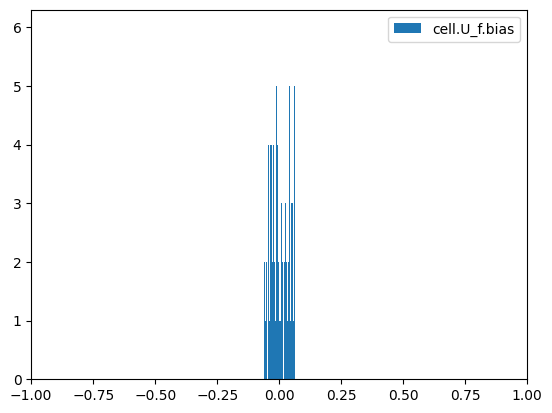

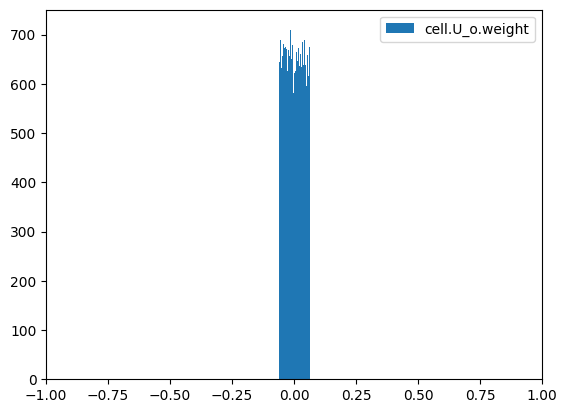

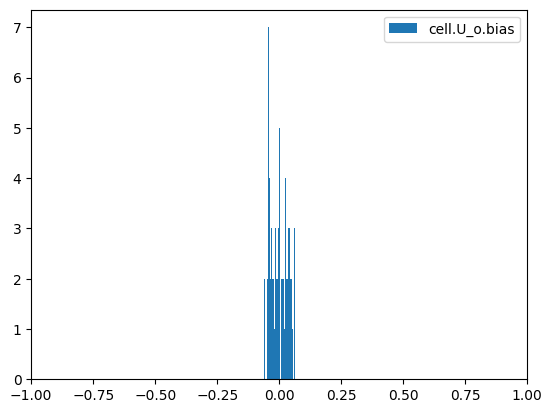

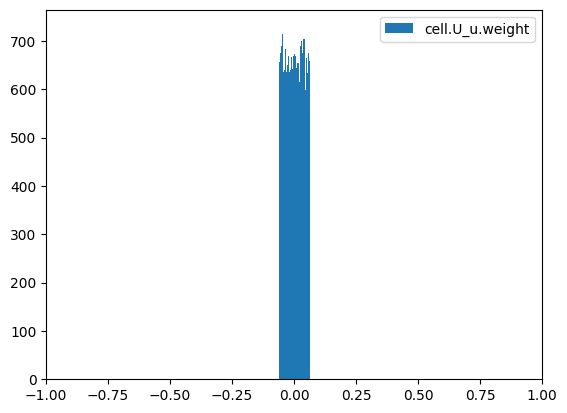

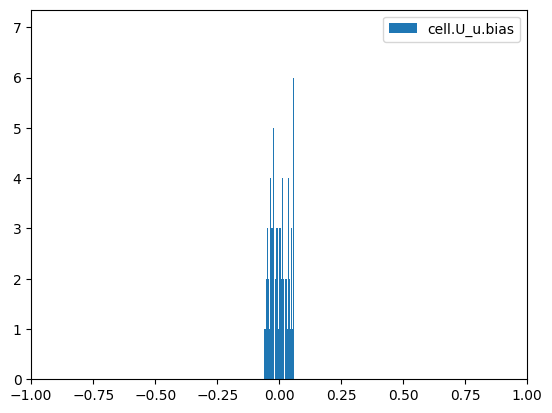

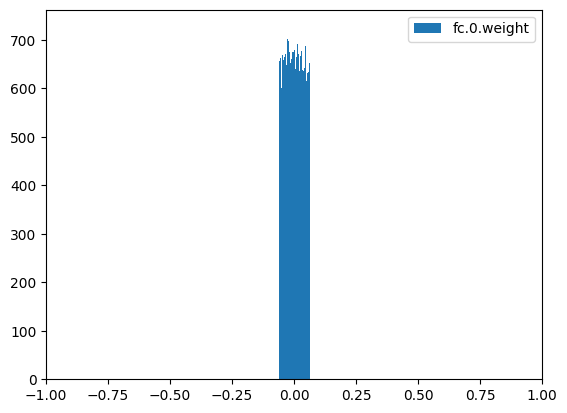

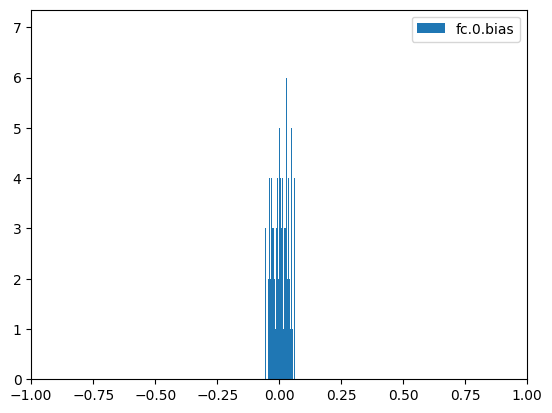

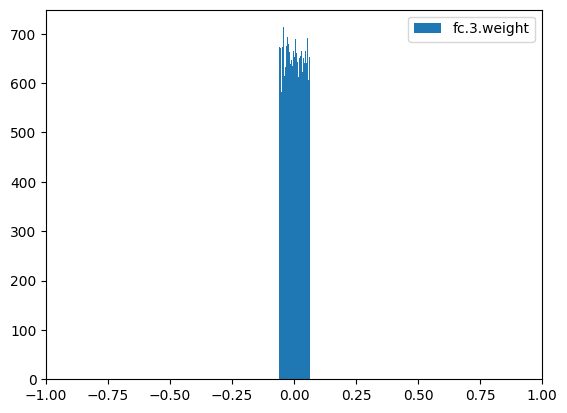

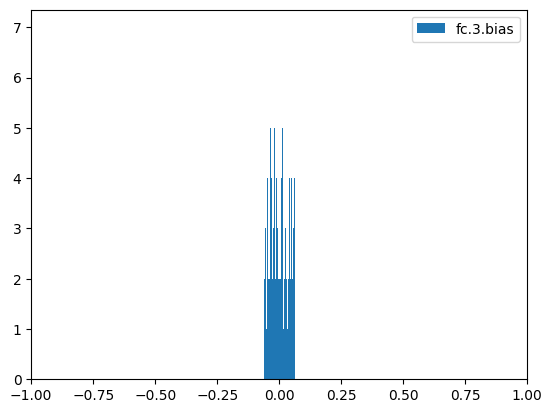

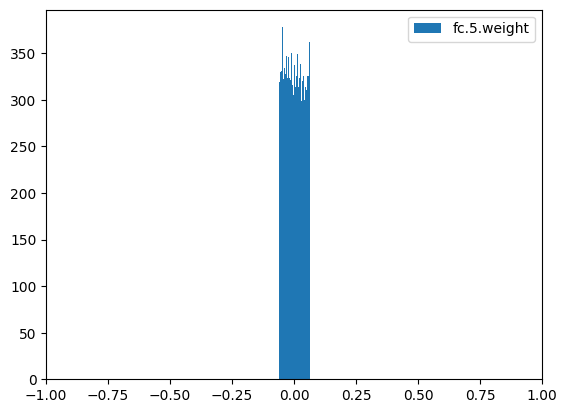

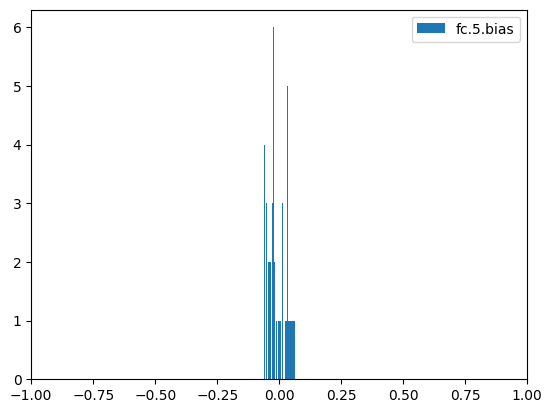

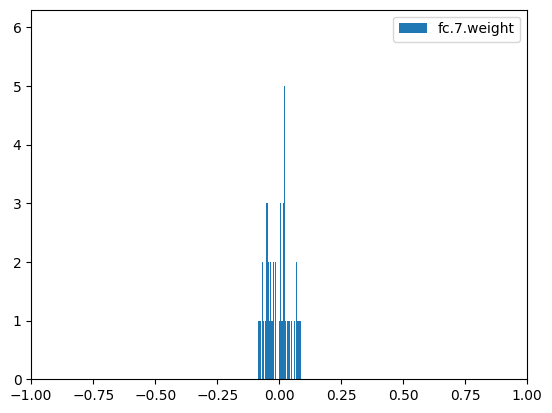

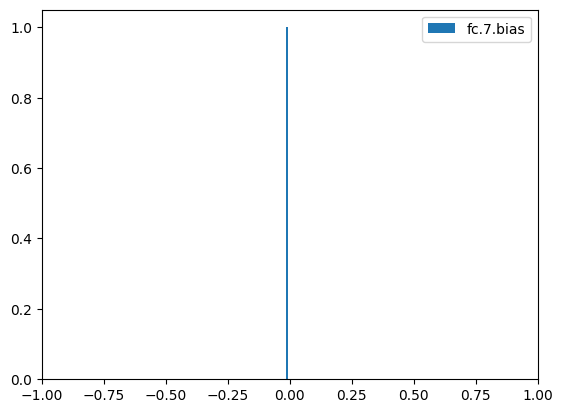

In [226]:
model.train()
for name, param in model.named_parameters():
    plt.xlim(-1e0,1e0)
    plt.hist(param.detach().cpu().flatten(), label=name, bins=100)
    plt.legend()
    plt.show()
    plt.close()